<a href="https://colab.research.google.com/github/vinicuervo/Calculo-Numerico/blob/main/atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Atividade 02 - Estabilidade e Overflow

Mariana Froes Grimaldi - 187574

Vinicius Cruz Cuervo - 185337



In [ ]:
# * BIBLIOTECAS *
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
# * VERIFICAÇÃO DA ESTABILIDADE *

H = 0.01          # distância entre placas (m)
nu = 1e-4         # viscosidade cinemática (m^2/s)
pontos = 21       # número de pontos na malha

delta_A = 0.001
delta_B = 0.002

# espaçamento espacial
delta_y = H / (pontos - 1)

# passo de tempo máximo permissível
delta_t_max = (delta_y**2) / (2 * nu)

r_A = (nu * delta_A) / (delta_y**2)
r_B = (nu * delta_B) / (delta_y**2)


print(f"Espaçamento espacial (dy): {delta_y:.4f} m")
print(f"Passo de tempo máximo (dt_max): {delta_t_max:.5f} s\n")

# classificação automática do Caso A
status_A = "Estável" if r_A <= 0.5 else "Instável"
print(f"Caso A (delta_t = {delta_A}s): r = {r_A:.2f} -> {status_A}")

# classificação automática do Caso B
status_B = "Estável" if r_B <= 0.5 else "Instável"
print(f"Caso B (delta_t = {delta_B}s): r = {r_B:.2f} -> {status_B}")

Espaçamento espacial (dy): 0.0005 m
Passo de tempo máximo (dt_max): 0.00125 s

Caso A (delta_t = 0.001s): r = 0.40 -> Estável
Caso B (delta_t = 0.002s): r = 0.80 -> Instável


┌──────────────────────────────────────────────────┐
│ Maior float32 representável: 3.403e+38  │
│ Maior float64 representável: 1.798e+308 │
└──────────────────────────────────────────────────┘

=== TABELA RESUMO DOS EXPERIMENTOS ===


,Tipo Numérico,dt (s),Valor de r,Estabilidade Teórica,Overflow?,Passo da Falha
0,float32,0.001,0.40,Estável,Não,—
1,float32,0.002,0.80,Instável,Sim ⚠️,121
2,float64,0.001,0.40,Estável,Não,—
3,float64,0.002,0.80,Instável,Sim ⚠️,917


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


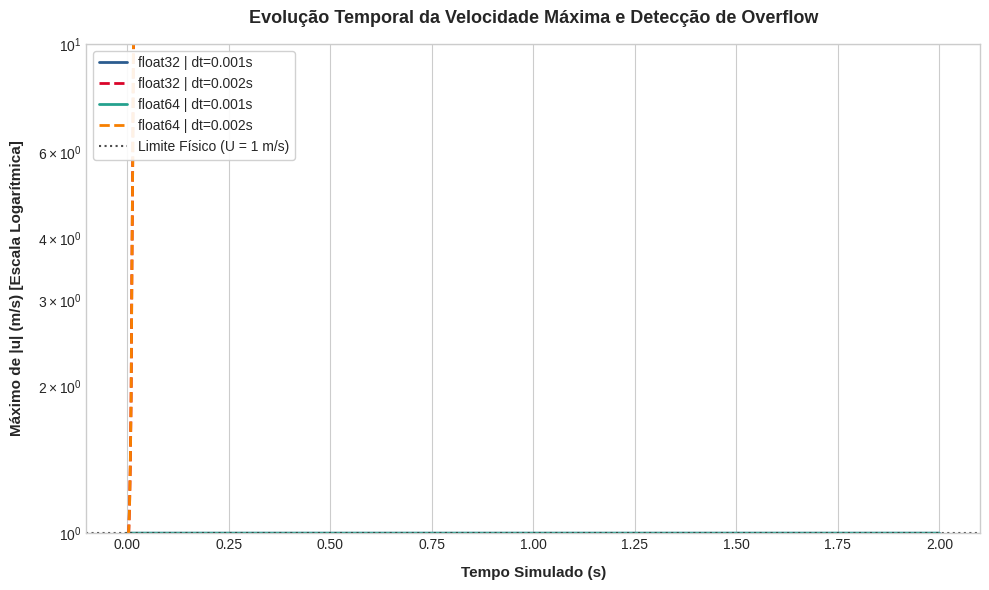

In [ ]:
# * FUNÇÃO DE SIMULAÇÃO *

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula a difusão de velocidade e detecta falhas por overflow."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1.0)  # condição de contorno (Placa em movimento)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                novo[1:-1] = u[1:-1] + r * (u[2:] - dois * u[1:-1] + u[:-2])
            except FloatingPointError:
                falha = passo
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }



# * EXECUÇÃO DOS CASOS DE TESTE *

tipos = [np.float32, np.float64]
passos_tempo = [0.001, 0.002]

resultados = {}
linhas_tabela = []

for tipo in tipos:
    for dt in passos_tempo:
        nome_teste = f"{tipo.__name__} | dt={dt}s"
        res = simular(dt, tipo)
        resultados[nome_teste] = res

        houve_overflow = res["falha"] is not None
        passo_falha = res["falha"] if houve_overflow else "—"
        estabilidade = "Estável" if res["r"] <= 0.5 else "Instável"

        linhas_tabela.append({
            "Tipo Numérico": tipo.__name__,
            "dt (s)": f"{dt:.3f}",
            "Valor de r": f"{res['r']:.2f}",
            "Estabilidade Teórica": estabilidade,
            "Overflow?": "Sim ⚠️" if houve_overflow else "Não",
            "Passo da Falha": passo_falha
        })

# * EXIBIÇÃO DA TABELA FORMATADA *

df_resultados = pd.DataFrame(linhas_tabela)

# exibe os limites físicos de memória
print("┌" + "─" * 50 + "┐")
print(f"│ Maior float32 representável: {np.finfo(np.float32).max:.3e}  │")
print(f"│ Maior float64 representável: {np.finfo(np.float64).max:.3e} │")
print("└" + "─" * 50 + "┘\n")

print("=== TABELA RESUMO DOS EXPERIMENTOS ===")
display(df_resultados)


# * GRÁFICO *

plt.figure(figsize=(10, 6), dpi=100)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

paleta_cores = {
    "float32 | dt=0.001s": "#2b5c8f",
    "float64 | dt=0.001s": "#25a18e",
    "float32 | dt=0.002s": "#d90429",
    "float64 | dt=0.002s": "#f77f00"
}

for nome, res in resultados.items():
    cor = paleta_cores.get(nome, None)
    estilo_linha = '--' if '0.002' in nome else '-'

    plt.semilogy(
        res["tempos"],
        res["maximos"],
        label=nome,
        linewidth=2,
        linestyle=estilo_linha,
        color=cor
    )

plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.7, label='Limite Físico (U = 1 m/s)')

plt.xlabel("Tempo Simulado (s)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Máximo de |u| (m/s) [Escala Logarítmica]", fontsize=11, fontweight='bold', labelpad=10)
plt.title("Evolução Temporal da Velocidade Máxima e Detecção de Overflow", fontsize=13, fontweight='bold', pad=15)

plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()


No gráfico, a curva das configurações instáveis ($r = 0,8$) apresenta uma linha reta ascendente em escala logarítmica, o que evidencia um crescimento exponencial da velocidade máxima ao longo do tempo até a ocorrência de *overflow*. Esse comportamento é totalmente não físico porque violaria o princípio do máximo. Como a única fonte de movimento no sistema é a placa inferior deslocando-se a $1\text{ m/s}$, a velocidade do fluido em qualquer ponto jamais poderia ultrapassar esse valor. O crescimento descontrolado ocorre puramente por uma falha do método numérico: quando $r > 0,5$, o coeficiente central da equação torna-se negativo, multiplicando e amplificando os pequenos erros de arredondamento a cada passo até "injetar" uma energia fictícia na simulação. Assim, o resultado perde o sentido físico muito antes do programa travar por estouro de memória.

A mudança do tipo numérico de `float32` para `float64` não elimina a instabilidade matemática do sistema.

A instabilidade ocorre por uma falha no método de discretização quando $r > 0,5$, o que faz com que os erros numéricos cresçam exponencialmente a cada passo de tempo. Mudar a precisão para `float64` apenas amplia a capacidade de armazenamento de memória: o `float32` atinge o estouro de memória (*overflow*) em torno de $10^{38}$, enquanto o `float64` consegue registrar valores de até aproximadamente $10^{308}$.

Portanto, o `float64` necessita de mais iterações para que o crescimento exponencial da velocidade alcance esse limite superior muito maior. Embora a simulação com `float64` rode por um número superior de passos até que o programa trave, a solução física já está completamente incorreta desde os primeiros instantes em que a velocidade ultrapassa $1\text{ m/s}$.


In [ ]:
# * REFINAMENTO DA MALHA (pontos = 41) *

H = 0.01
nu = 1e-4
pontos_novos = 41

# novo espaçamento e novo limite de estabilidade
dy_novo = H / (pontos_novos - 1)
dt_max_novo = (dy_novo**2) / (2 * nu)

print(f"Novo delta y (41 pontos): {dy_novo:.6f} m")
print(f"Novo delta t máximo: {dt_max_novo:.6f} s\n")

# Teste A: mantendo dt = 0.001s (deve ficar instável pois 0.001s > 0.0003125s)
res_41_instavel = simular(dt=0.001, tipo=np.float64, pontos=41)

# Teste B: escolhendo um dt seguro abaixo do novo limite (ex: dt = 0.0002s)
dt_seguro = 0.0002
res_41_estavel = simular(dt=dt_seguro, tipo=np.float64, pontos=41)

Novo delta y (41 pontos): 0.000250 m
Novo delta t máximo: 0.000312 s



Ao refinar a malha para 41 pontos, o espaçamento reduz para metade, tornando $\Delta y = 0,00025\text{ m}$. Como o limite de estabilidade depende do quadrado do espaçamento, o novo tempo máximo permitido cai para $\Delta t_{max} = 0,0003125\text{ s}$. Por essa razão, ao manter $\Delta t = 0,001\text{ s}$, a simulação torna-se instável e apresenta falha, uma vez que o passo de tempo utilizado supera o novo limite teórico em mais de três vezes. Ao reajustar o passo de tempo para um valor seguro abaixo do novo limite, como $\Delta t = 0,0002\text{ s}$, o parâmetro $r$ retorna a um valor inferior a $0,5$, garantindo a estabilidade numérica da simulação sem ocorrência de estouro de memória.


Erro máximo em relação ao perfil estacionário (E_inf): 3.275769e-05 m/s


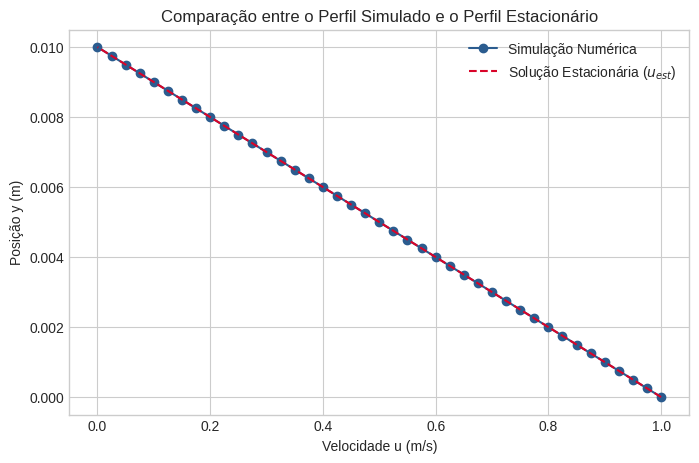

In [ ]:
# * VERIFICAÇÃO DO PERFIL DE VELOCIDADE ESTACIONÁRIO *

# execução estável e longa (passos=5000 com dt=0.0002s para atingir o regime permanente)
res_longo = simular(dt=dt_seguro, tipo=np.float64, passos=5000, pontos=41)

y_malha = res_longo["y"]
u_numerico = res_longo["u"]
U = 1.0

# solução analítica estacionária: u_est(y) = U * (1 - y/H)
u_estacionario = U * (1 - y_malha / H)

# erro máximo da norma infinito
E_inf = np.max(np.abs(u_numerico - u_estacionario))

print(f"\nErro máximo em relação ao perfil estacionário (E_inf): {E_inf:.6e} m/s")

# gráfico de comparação dos perfis
plt.figure(figsize=(8, 5))
plt.plot(u_numerico, y_malha, 'o-', color='#2b5c8f', label='Simulação Numérica')
plt.plot(u_estacionario, y_malha, '--', color='#d90429', label='Solução Estacionária ($u_{est}$)')
plt.xlabel("Velocidade u (m/s)")
plt.ylabel("Posição y (m)")
plt.title("Comparação entre o Perfil Simulado e o Perfil Estacionário")
plt.grid(True)
plt.legend()
plt.show()

Ao comparar o perfil final de velocidades obtido pela simulação de longa duração com a solução analítica estacionária $u_{est}(y) = U(1 - y/H)$, observa-se uma sobreposição quase perfeita entre os pontos numéricos e a reta teórica. O valor extremamente pequeno encontrado para o erro máximo $E_{\infty}$ confirma que o tempo total simulado foi plenamente suficiente para que os efeitos transientes iniciais da difusão de viscosidade fossem superados, permitindo ao sistema atingir com precisão o regime permanente esperado.  

## Conclusão

O refinamento da malha espacial aumenta a precisão geométrica do domínio, porém impõe um custo severo sobre o avanço temporal, pois o limite de estabilidade reduz-se quadraticamente com a diminuição de $\Delta y$. Quando o passo de tempo ultrapassa esse limite restritivo, o esquema explícito desenvolve uma instabilidade numérica que injeta energia não física no sistema, acumulando erros de arredondamento que resultam inevitavelmente em overflow. Portanto, a alteração fundamental que corrigiu a causa da falha nesta simulação foi o redimensionamento adequado do passo de tempo $\Delta t$ para manter o parâmetro de difusão $r \le 0,5$, respeitando rigorosamente a condição de estabilidade do método numérico.  